Python ejecutable desde: c:\Users\isilva\.conda\envs\metodos\python.exe

¡NumPy funciona de 10! Matriz A_transpuesta*A simulada:
 [[2 1]
 [1 3]]


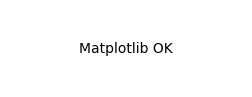

¡Entorno configurado correctamente para el TP2!


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# 1. Verificar qué Python se está ejecutando realmente
print("Python ejecutable desde:", sys.executable)

# 2. Probar que NumPy y Matplotlib respondan bien
try:
    A = np.array([[2, 1], [1, 3]])
    print("\n¡NumPy funciona de 10! Matriz A_transpuesta*A simulada:\n", A)
    
    plt.figure(figsize=(3,1))
    plt.text(0.5, 0.5, "Matplotlib OK", ha='center', va='center')
    plt.axis('off')
    plt.show()
    print("¡Entorno configurado correctamente para el TP2!")
except Exception as e:
    print(f"\nOjo, algo falló: {e}")

# Ejercicio 1: Funciones base de Bernstein
Punto C: 

### Demostración Algebraica de la Partición de la Unidad

Primero desglosamos y expandimos cada uno de los polinomios:

$$b_{0}(t) = (1-t)^3 = 1 - 3t + 3t^2 - t^3$$
$$b_{1}(t) = 3(1-t)^2t = 3(1 - 2t + t^2)t = 3t - 6t^2 + 3t^3$$
$$b_{2}(t) = 3(1-t)t^2 = 3t^2 - 3t^3$$
$$b_{3}(t) = t^3$$

Después sumamos las cuatro expresiones miembro a miembro:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = (1 - 3t + 3t^2 - t^3) + (3t - 6t^2 + 3t^3) + (3t^2 - 3t^3) + (t^3)$$

Agrupamos los términos según la potencia de $t$:

* **Término independiente:** $1$
* **Términos con $t$:** $-3t + 3t = 0$
* **Términos con $t^2$:** $3t^2 - 6t^2 + 3t^2 = 0$
* **Términos con $t^3$:** $-t^3 + 3t^3 - 3t^3 + t^3 = 0$

Y listo: al cancelarse todos los términos dependientes de $t$, llegamos al resultado final:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = 1, \quad \forall t \in [0, 1]$$

Punto D:

Esto valida la razón por la que consideramos que la curva es una combinación convexa de los puntos de control. Sabemos que las funciones son siempre mayores o iguales a cero en el intervalo $[0,1]$ y como vimos su suma da exactamente $1$. Las funciones de base de Berstein actuan como pesos de cada punto de control y como suman 1 se refuerza esa idea de combinación convexa de puntos de control.


Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:
 
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.70002030e-01 2.96939397e-02 3.02999385e-04 1.03061015e-06]
 [9.40610059e-01 5.81820655e-02 1.19963022e-03 8.24488122e-06]
 [9.11817904e-01 8.54829285e-02 2.67134151e-03 2.78264741e-05]
 [8.83619379e-01 1.11615079e-01 4.69958229e-03 6.59590497e-05]
 [8.56008303e-01 1.36597070e-01 7.26580157e-03 1.28826269e-04]
 [8.28978490e-01 1.60447450e-01 1.03514484e-02 2.22611793e-04]
 [8.02523758e-01 1.83184771e-01 1.39379717e-02 3.53499282e-04]
 [7.76637923e-01 2.04827584e-01 1.80068206e-02 5.27672398e-04]
 [7.51314801e-01 2.25394440e-01 2.25394440e-02 7.51314801e-04]
 [7.26548208e-01 2.44903890e-01 2.75172911e-02 1.03061015e-03]
 [7.02331962e-01 2.63374486e-01 3.29218107e-02 1.37174211e-03]
 [6.78659877e-01 2.80824777e-01 3.87344520e-02 1.78089434e-03]
 [6.55525771e-01 2.97273315e-01 4.49366639e-02 2.26425050e-03]
 [6.32

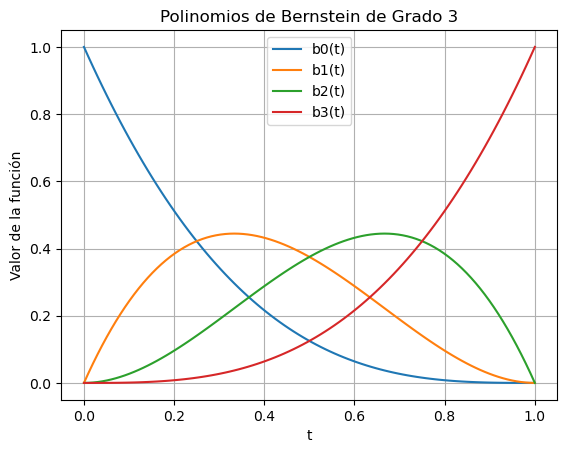

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def bernstein3(t: np.ndarray) -> np.ndarray:

    b0: np.ndarray = (1 - t)**3 
    b1: np.ndarray = 3 * (1 - t)**2 * t 
    b2: np.ndarray = 3 * (1 - t) * t**2 
    b3: np.ndarray = t**3 
    
    # matriz_base es un np.ndarray, pero cambia su forma a una bidimensional de tipo (m, 4)
    matriz_base: np.ndarray = np.column_stack((b0, b1, b2, b3))
    return matriz_base

#estos son mis 100 valores de t
t_real: np.ndarray = np.linspace(0, 1, 100) 
resultado: np.ndarray = bernstein3(t_real)

print("Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:")
print(" ")
print(resultado)

print("Y ahora graficamos las 4 funciones en el intervalo [0,1]")
t = np.linspace(0, 1, 100)

matriz = bernstein3(t)

# grafico cada columna. En NumPy, matriz[:, 0] significa "toda la columna 0"
plt.plot(t, matriz[:, 0], label="b0(t)")  # grafica b0
plt.plot(t, matriz[:, 1], label="b1(t)")  # grafica b1
plt.plot(t, matriz[:, 2], label="b2(t)")  # grafica b2
plt.plot(t, matriz[:, 3], label="b3(t)")  # grafica b3 

plt.title("Polinomios de Bernstein de Grado 3")
plt.xlabel("t")
plt.ylabel("Valor de la función")
plt.legend()  # muestra el cartelito de qué color es cada función
plt.grid(True) 

plt.show()